In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [4]:
transform = transforms.ToTensor()

In [5]:
train_data = datasets.MNIST(root='../Data',train=True, download=True, transform=transform)

In [6]:
test_data = datasets.MNIST(root='../Data',train=False, download=True, transform=transform)

In [7]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [8]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [9]:
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data,batch_size=10, shuffle=False)

In [10]:
class ConvulutionalNetwork(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        self.fc1 = nn.Linear(5*5*16,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)
        
    def forward(self,X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X,2,2)
        X = X.view(-1,16*5*5)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X,dim=1)

In [11]:
torch.manual_seed(42)
model = ConvulutionalNetwork()
model

ConvulutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [17]:
import time
start_time = time.time()

# Trackers
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []
#Epochs
for i in range (epochs):
    
    trn_corr = 0
    test_corr = 0
    # Train
    
    for b,(X_train, y_train) in enumerate(train_loader):
        b+=1
        
        y_pred = model(X_train) # Not flatten
        loss = criterion(y_pred, y_train)
        
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum() # True 1/False 0
        trn_corr += batch_corr
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if b%600 == 0:
            print(f"Epoch: {i} Batch: {b} Loss: {loss.item()}")
                  
    train_losses.append(loss)
    train_correct.append(trn_corr)
    #Test
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
                  
            y_val = model(X_test)
            predicted = torch.max(y_val.data,1)[1]
            test_corr += (predicted == y_test).sum()


    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(test_corr)


current_time = time.time()
total = current_time - start_time
print(f"Training took {total/60} minutes")

Epoch: 0 Batch: 600 Loss: 0.0010636062361299992
Epoch: 0 Batch: 1200 Loss: 0.0005286068189889193
Epoch: 0 Batch: 1800 Loss: 1.733231511025224e-05
Epoch: 0 Batch: 2400 Loss: 0.040413737297058105
Epoch: 0 Batch: 3000 Loss: 0.0018194362055510283
Epoch: 0 Batch: 3600 Loss: 0.0020974234212189913
Epoch: 0 Batch: 4200 Loss: 0.0017138362163677812
Epoch: 0 Batch: 4800 Loss: 0.283461332321167
Epoch: 0 Batch: 5400 Loss: 0.0019722571596503258
Epoch: 0 Batch: 6000 Loss: 0.009187038987874985
Epoch: 1 Batch: 600 Loss: 4.2027422750834376e-05
Epoch: 1 Batch: 1200 Loss: 0.0005905033322051167
Epoch: 1 Batch: 1800 Loss: 0.002751495223492384
Epoch: 1 Batch: 2400 Loss: 0.0007547988789156079
Epoch: 1 Batch: 3000 Loss: 0.000610388582572341
Epoch: 1 Batch: 3600 Loss: 0.2633157968521118
Epoch: 1 Batch: 4200 Loss: 7.812727562850341e-05
Epoch: 1 Batch: 4800 Loss: 5.013450208934955e-05
Epoch: 1 Batch: 5400 Loss: 0.011720387265086174
Epoch: 1 Batch: 6000 Loss: 0.001292454544454813
Epoch: 2 Batch: 600 Loss: 0.000933

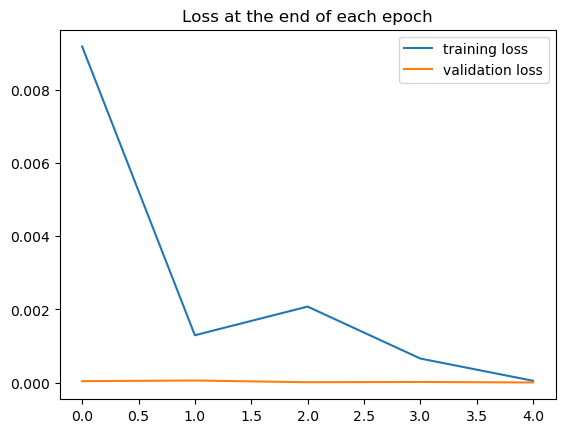

In [18]:
plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend();

In [19]:
test_losses

[tensor(3.7620e-05),
 tensor(5.5066e-05),
 tensor(8.2491e-06),
 tensor(1.5544e-05),
 tensor(1.0848e-06)]

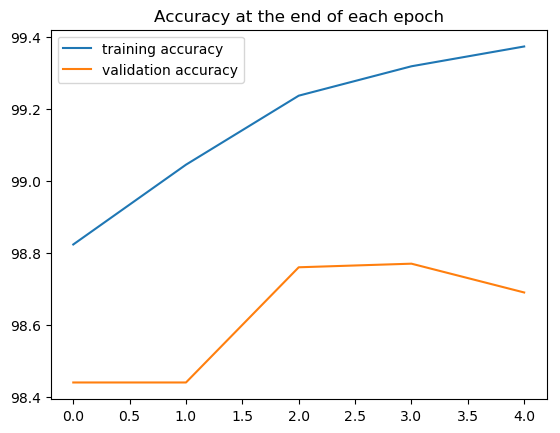

In [20]:
plt.plot([t/600 for t in train_correct], label='training accuracy')
plt.plot([t/100 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();

In [21]:
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

In [22]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        y_val = model(X_test)  # we don't flatten the data this time
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()
print(f'Test accuracy: {correct.item()}/{len(test_data)} = {correct.item()*100/(len(test_data)):7.3f}%')

Test accuracy: 9869/10000 =  98.690%
